In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from pint import UnitRegistry
from photonmover.utils.hdf5_utils import *
from scipy.optimize import curve_fit
from scipy.signal import find_peaks, savgol_filter, hilbert
from scipy.interpolate import make_smoothing_spline


plt.rcParams['font.size'] = 14

u = UnitRegistry()
Q_ = u.Quantity

data_dir = Path.home() / 'OneDrive\Documents\data\probe_station'


# Configure OSA

In [204]:
from photonmover.instruments.Optical_spectrum_analyzers.HP70951B import HP70951B

osa = HP70951B()
osa.initialize()

ref_level = Q_(-15, 'dBm') #[dBm]
rbw = 0.1 * u.nm #[nm]
vbw = 200 * u.Hz
sensitivity = Q_(-50, 'dBm') #[dBm]
span = None #800 * u.nm 
center = None #1300 * u.nm 
start_wl = 800 * u.nm 
end_wl = 1000 * u.nm 
trace_length = 2048

osa.set_wl_axis(start_wl=f"{start_wl.to(u.nm).m} NM", end_wl=f"{end_wl.to(u.nm).m} NM")
osa.set_reference_level(ref_value=ref_level.m, ref_pos=None)
osa.set_sensitivity(sens=sensitivity.m)
osa.set_acq_bandwidth(res_bw = f"{rbw.to(u.nm).m} NM", video_bw = f"{vbw.to(u.Hz).m} HZ")
osa.set_trace_length(trace_length=trace_length)

Opening connnection to HP OSA
timeout=500000


start: 600 nanometer
stop: 700 nanometer 

start: 700 nanometer
stop: 800 nanometer 

start: 800 nanometer
stop: 900 nanometer 

start: 900 nanometer
stop: 1000 nanometer 

start: 1000 nanometer
stop: 1100 nanometer 

start: 1100 nanometer
stop: 1200 nanometer 

start: 1200 nanometer
stop: 1300 nanometer 

start: 1300 nanometer
stop: 1400 nanometer 

start: 1400 nanometer
stop: 1500 nanometer 

start: 1500 nanometer
stop: 1600 nanometer 

start: 1600 nanometer
stop: 1700 nanometer 

dumping item: wavelength
dumping item: amplitude
dumping item: psd
dumping item: rbw
dumping item: sensitivity
dumping item: reference level


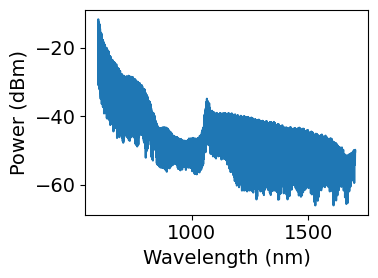

In [196]:
def acquire_spectra(osa_params, fname=None, sample_dir=None, verbose=True):
    # Acquire a spectra by stitching together segments of length span
    
    rbw = osa_params["rbw"]
    vbw = osa_params["vbw"]
    
    osa.set_reference_level(ref_value=osa_params["ref_level"].m, ref_pos=None)
    osa.set_sensitivity(sens=osa_params["sensitivity"].m)
    osa.set_acq_bandwidth(res_bw = f"{rbw.to(u.nm).m} NM", video_bw = f"{vbw.to(u.Hz).m} HZ")
    osa.set_trace_length(trace_length=osa_params["trace_length"])
    
    full_span = osa_params["stop_wl"] - osa_params["start_wl"]
    num_seg = int(full_span // osa_params["span"])
    
    # Create moving window of length span and store in array
    wavelength = np.zeros((num_seg * osa_params["trace_length"],))
    amplitude = np.zeros((num_seg * osa_params["trace_length"],))

    for i in range(num_seg):
        start_wl = osa_params["start_wl"] + i * osa_params["span"] 
        stop_wl = start_wl + osa_params["span"]
        span = int(osa_params["span"].to(u.nm).m)
        osa.set_wl_axis(start_wl=f"{start_wl.to(u.nm).m} NM", end_wl=f"{stop_wl.to(u.nm).m} NM")

        print(f"start: {start_wl}")
        print(f"stop: {stop_wl} \n")
        [wavs, amps] = osa.read_data()
        
        wavelength[i*osa_params["trace_length"]: (i+1)*osa_params["trace_length"]] = wavs
        amplitude[i*osa_params["trace_length"]: (i+1)*osa_params["trace_length"]] = amps

    psd = amplitude - 10*np.log10(rbw.to(u.nm).m)

    if fname is not None:
        [_, meas_params] = osa.get_osa_parameters()

        time_stamp = new_timestamp()
        fpath = data_dir / sample_dir / Path(fname + '_' + time_stamp + '.h5')
        
        dump_hdf5({
            "wavelength":   wavelength * u.m,
            "amplitude":    Q_(amplitude, 'dBm'),
            'psd':          psd, #dBm/nm
            "rbw":          meas_params["rbw"] * u.m,
            "sensitivity":   Q_(meas_params["sensitivity"], 'dBm'),
            "reference level":  Q_(meas_params['reference level'], 'dBm')
            }, 
            fpath=fpath, 
            open_mode='x'
        )
    
    if verbose:
        fig, ax = plt.subplots(1,1, figsize=(4,3), tight_layout=True)
        ax.plot(wavelength * 1e9, amplitude)
        ax.set_xlabel("Wavelength (nm)")
        ax.set_ylabel("Power (dBm)")
        
    return wavelength, amplitude


fname = "MZI_UFBS5050_stitch100nm_600-1700nm_rbw0.1nm_2"
sample_dir = "BB_dispersion_setup"

osa_params = dict(
    start_wl = 600 * u.nm, 
    stop_wl = 1700 * u.nm, 
    span = 100 * u.nm, 
    rbw = 0.1 * u.nm, 
    vbw = 200 * u.Hz,
    sensitivity = Q_(-50, 'dBm'), 
    ref_level = Q_(-15, 'dBm'),
    trace_length = 2048
)

wavelength, amplitude = acquire_spectra(osa_params, fname=fname, sample_dir=sample_dir)
        
        

# Record OSA NOISE FLOOR trace 

In [ ]:
fname = "supercont_osa_noiseFloor_rbw0.1nm"
sample_dir = "BB_dispersion_setup"


time_stamp = new_timestamp()
fpath = data_dir / sample_dir / Path(fname + '_' + time_stamp + '.h5')

[wavs1, amps1] = osa.read_data()
[_, osa_params] = osa.get_osa_parameters()

psd1 = amps1 - 10*np.log10(rbw.to(u.nm).m)

dump_hdf5({
    "wavelength":   wavs1 * u.m,
    "amplitude":    Q_(amps1, 'dBm'),
    'psd':          psd1,
    "rbw":          osa_params["rbw"] * u.m,
    "sensitivity":   Q_(osa_params["sensitivity"], 'dBm'),
    "reference level":  Q_(osa_params['reference level'], 'dBm')
    }, 
    fpath=fpath, 
    open_mode='x'
)

dumping item: wavelength
dumping item: amplitude
dumping item: psd
dumping item: rbw
dumping item: sensitivity
dumping item: reference level


# Record DEVICE trace 

dumping item: wavelength
dumping item: amplitude
dumping item: psd
dumping item: rbw
dumping item: sensitivity
dumping item: reference level
Trace Length: 2048


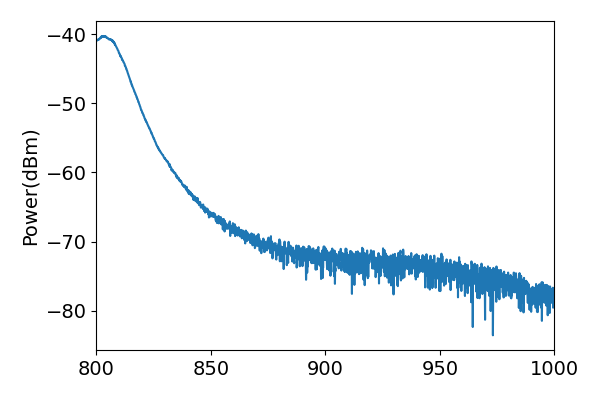

In [205]:
fname = "superlum_800-1000nm_RBW0.1nm_oscDebug"

sample_dir = "BB_dispersion_setup"
data_dir = Path.home() / 'OneDrive\Documents\data\probe_station'
time_stamp = new_timestamp()
fpath = data_dir / sample_dir / Path(fname + '_' + time_stamp + '.h5')

[wavs, amps] = osa.read_data()
[_, osa_params] = osa.get_osa_parameters()

psd = amps - 10*np.log10(rbw.to(u.nm).m)

dump_hdf5({
    "wavelength":   wavs * u.m,
    "amplitude":    Q_(amps, 'dBm'),
    'psd':          psd,
    "rbw":          osa_params["rbw"] * u.m,
    "sensitivity":   Q_(osa_params["sensitivity"], 'dBm'),
    "reference level":  Q_(osa_params['reference level'], 'dBm')
    }, 
    fpath=fpath, 
    open_mode='x'
)
fig, ax = plt.subplots(1, 1, figsize=(6,4), tight_layout=True)
ax.plot(wavs*1e9, amps)
# ax.plot(wavs1*1e9, amps1, color='silver')
ax.set_ylabel('Power(dBm)')
ax.set_xlim((min(wavs)*1e9, max(wavs)*1e9))

print(f"Trace Length: {wavs.shape[0]}")

start: 1000 nanometer
stop: 1200 nanometer 

dumping item: wavelength
dumping item: amplitude
dumping item: psd
dumping item: rbw
dumping item: sensitivity
dumping item: reference level
start: 1000 nanometer
stop: 1200 nanometer 

dumping item: wavelength
dumping item: amplitude
dumping item: psd
dumping item: rbw
dumping item: sensitivity
dumping item: reference level
start: 1000 nanometer
stop: 1200 nanometer 

dumping item: wavelength
dumping item: amplitude
dumping item: psd
dumping item: rbw
dumping item: sensitivity
dumping item: reference level


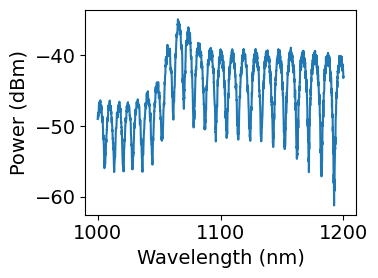

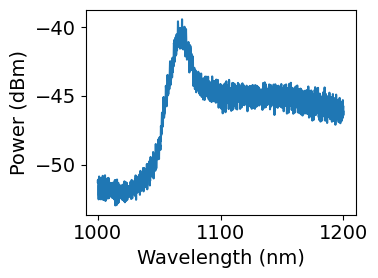

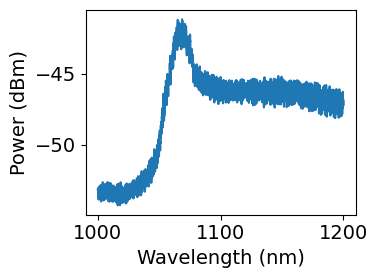

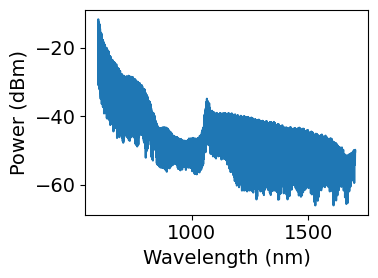

In [199]:
from instrumental.drivers.daq.ni import Task # NIDAQ2,
from instrumental import instrument

# Initialize instruments
# daq = instrument("NIDAQ_USB-6259", reopen_policy='reuse')
daq2 = instrument("NIDAQ_USB-6259_2", reopen_policy='reuse')


def unblock_sample_arm():
    daq2.port1.write(0x01)
    
def block_sample_arm():
    daq2.port1.write(0x00)
    
def unblock_ref_arm():
    daq2.port0.write(0x01)
    
def block_ref_arm():
    daq2.port0.write(0x00)
    
def set_osa_params(osa_params):
    # Set osa parameters for acquisition
    rbw = osa_params["rbw"]
    vbw = osa_params["vbw"]
    start_wl = osa_params["start_wl"]
    stop_wl = osa_params["stop_wl"]
    
    osa.set_reference_level(ref_value=osa_params["ref_level"].m, ref_pos=None)
    osa.set_sensitivity(sens=osa_params["sensitivity"].m)
    osa.set_acq_bandwidth(res_bw = f"{rbw.to(u.nm).m} NM", video_bw = f"{vbw.to(u.Hz).m} HZ")
    osa.set_trace_length(trace_length=osa_params["trace_length"])    
    osa.set_wl_axis(start_wl=f"{start_wl.to(u.nm).m} NM", end_wl=f"{stop_wl.to(u.nm).m} NM")
    
def acquire_spectra(osa_params, fname=None, sample_dir=None, verbose=True):
    # Acquire a spectra by stitching together segments of length span
    
    set_osa_params(osa_params)
    
    full_span = osa_params["stop_wl"] - osa_params["start_wl"]
    num_seg = int(full_span // osa_params["span"])
    
    # Create moving window of length span and store in array
    wavelength = np.zeros((num_seg * osa_params["trace_length"],))
    amplitude = np.zeros((num_seg * osa_params["trace_length"],))

    for i in range(num_seg):
        start_wl = osa_params["start_wl"] + i * osa_params["span"] 
        stop_wl = start_wl + osa_params["span"]
        span = int(osa_params["span"].to(u.nm).m)
        osa.set_wl_axis(start_wl=f"{start_wl.to(u.nm).m} NM", end_wl=f"{stop_wl.to(u.nm).m} NM")

        print(f"start: {start_wl}")
        print(f"stop: {stop_wl} \n")
        [wavs, amps] = osa.read_data()
        
        wavelength[i*osa_params["trace_length"]: (i+1)*osa_params["trace_length"]] = wavs
        amplitude[i*osa_params["trace_length"]: (i+1)*osa_params["trace_length"]] = amps

    psd = amplitude - 10*np.log10(rbw.to(u.nm).m)

    if fname is not None:
        [_, meas_params] = osa.get_osa_parameters()

        time_stamp = new_timestamp()
        fpath = data_dir / sample_dir / Path(fname + '_' + time_stamp + '.h5')
        
        dump_hdf5({
            "wavelength":   wavelength * u.m,
            "amplitude":    Q_(amplitude, 'dBm'),
            'psd':          psd, #dBm/nm
            "rbw":          meas_params["rbw"] * u.m,
            "sensitivity":   Q_(meas_params["sensitivity"], 'dBm'),
            "reference level":  Q_(meas_params['reference level'], 'dBm')
            }, 
            fpath=fpath, 
            open_mode='x'
        )
    
    if verbose:
        fig, ax = plt.subplots(1,1, figsize=(4,3), tight_layout=True)
        ax.plot(wavelength * 1e9, amplitude)
        ax.set_xlabel("Wavelength (nm)")
        ax.set_ylabel("Power (dBm)")
        
    return wavelength, amplitude

    
def acquire_normalized_spectra(osa_params, fname=None, sample_dir=None, verbose=True):
    # Acquire a spectra by stitching together segments of length span. Also acquire single-arm spectra by blocking the sample arm and reference arms.
    
    # Create filenames
    mzi_fname = "MZI_" + fname
    samp_fname = "SAMP_" + fname
    ref_fname = "REF_" + fname
    
    # Acquire interference fringes - both shutters open
    unblock_ref_arm()
    unblock_sample_arm()
    mzi_wav, mzi_amp = acquire_spectra(osa_params=osa_params, fname=mzi_fname, sample_dir=sample_dir, verbose=verbose)
    
    # Acquire sample arm only spectra - close reference shutter
    block_ref_arm()
    samp_wav, samp_amp = acquire_spectra(osa_params=osa_params, fname=samp_fname, sample_dir=sample_dir, verbose=verbose)
    unblock_ref_arm()
    
    # Acquire ref arm only spectra - close sample shutter
    
    block_sample_arm()
    ref_wav, samp_amp = acquire_spectra(osa_params=osa_params, fname=ref_fname, sample_dir=sample_dir, verbose=verbose)
    unblock_sample_arm()
    
    if verbose:
        fig, ax = plt.subplots(1,1, figsize=(4,3), tight_layout=True)
        ax.plot(wavelength * 1e9, amplitude)
        ax.set_xlabel("Wavelength (nm)")
        ax.set_ylabel("Power (dBm)")
        
    return wavelength, amplitude


fname = "UFBS5050_stitch200nm_1000-1200nm_rbw0.1nm_2"
sample_dir = "BB_dispersion_setup"

osa_params = dict(
    start_wl = 1000 * u.nm, 
    stop_wl = 1200 * u.nm, 
    span = 200 * u.nm, 
    rbw = 0.1 * u.nm, 
    vbw = 200 * u.Hz,
    sensitivity = Q_(-50, 'dBm'), 
    ref_level = Q_(-15, 'dBm'),
    trace_length = 2048
)

wavelength, amplitude = acquire_normalized_spectra(osa_params, fname=fname, sample_dir=sample_dir)
        
        
        


# Raw data visualization

In [190]:
unblock_ref_arm()
unblock_sample_arm()

In [188]:
block_sample_arm()
# block_ref_arm()

loading file: MZI_UFBS5050_stitch100nm_600-1700nm_rbw0.1nm_2_2026-05-10-23-42-57.h5
importing amplitude...
importing psd...
importing rbw...
importing reference level...
importing sensitivity...
importing wavelength...
loading file: MZI_UFBS5050_stitch100nm_600-1700nm_rbw0.1nm_1_2026-05-10-23-37-45.h5
importing amplitude...
importing psd...
importing rbw...
importing reference level...
importing sensitivity...
importing wavelength...
loading file: MZI_UFBS5050_stitch100nm_600-1700nm_rbw0.1nm_0_2026-05-10-23-22-17.h5
importing amplitude...
importing psd...
importing rbw...
importing reference level...
importing sensitivity...
importing wavelength...


c:\Users\euyehara\miniconda3\envs\photonmover\lib\site-packages\matplotlib\cbook\__init__.py:1369: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


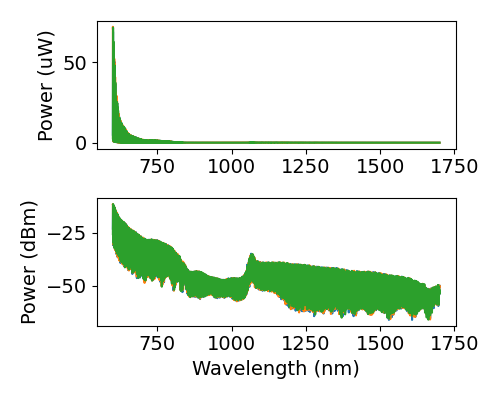

In [3]:
%matplotlib ipympl

data_dir = Path.home() / 'OneDrive\Documents\data\probe_station'
sample_dir = "BB_dispersion_setup"

# ------------------------------------------------------------
# 4/20/26 Test BSW29R 50:50 BS for fabry-perot oscillations
# fname_noise = "supercont_osa_noiseFloor_2026-04-20-01-08-49.h5"
fname_mzi = [
#                 "double_BSW29R_Nikon20x_noRefArm_1_2026-04-20-01-43-02.h5",
#                 "single_BSW29R_Nikon20x_noRefArm_1_2026-04-20-01-39-49.h5",
#                 "supercont_probe-to-probe_OBJ_mirror_2026-04-20-01-46-32.h5" # Control - no BSW29R (gold mirror)
                "supercont_LMA-PM-10_osa_2026-04-25-00-29-54.h5", #850-1250 nm # Redo higher res - control, straight from fiber
#                 "noObj_850-1250nm_RBW0.1nm_noBSW29R_v2_2026-04-24-23-57-02.h5", # Redo higher res 
#                 "noObj_850-1250nm_RBW0.1nm_BSW29R_BS1_v2_2026-04-24-23-51-22.h5", # Redo higher res 
#                 "noObj_850-1250nm_RBW0.1nm_BSW29R_BS2_v2_2026-04-24-23-58-43.h5", # Redo higher res 
                ]
# ------------------------------------------------------------
# 4/23/26 First MZI measurements, no objectives or sample 
fname_noise = [
    "supercont_osa_noiseFloor_2026-04-23-01-06-32.h5", #rbw 1nm
    "supercont_osa_noiseFloor_rbw0.1nm_2026-04-23-01-20-51.h5",
    "supercont_osa_noiseFloor_rbw0.5nm_2026-04-23-01-13-44.h5", 
]
# fname_mzi = [
    ## Full span acquisitions with varying RBW -------
    # "noObj_600-1700nm_RBW1nm_2026-04-23-01-08-02.h5",
    # "noObj_600-1700nm_RBW0.5nm_2026-04-23-01-16-36.h5",
    # "noObj_600-1700nm_RBW0.1nm_2026-04-23-01-22-24.h5",
    ## Shorter span acquisitions ---------------------
    # "noObj_600-850nm_RBW0.1nm_2026-04-23-01-26-20.h5",
    # "noObj_850-1250nm_RBW0.1nm_2026-04-23-01-29-29.h5",
    # "noObj_850-1250nm_RBW0.1nm_blockRef_2026-04-23-01-30-39.h5",
    # "noObj_850-1250nm_RBW0.1nm_blockSamp_2026-04-23-01-31-58.h5",
    # "noObj_1250-1700nm_RBW1nm_2026-04-23-01-37-21.h5",
    # "noObj_1250-1700nm_RBW0.1nm_2026-04-23-01-35-03.h5"
# ]

# fname_ref = "noObj_850-1250nm_RBW0.1nm_blockRef_2026-04-23-01-30-39.h5"
#"noObj_850-1250nm_RBW0.1nm_blockSamp_2026-04-23-01-31-58.h5"
# ------------------------------------------------------------
# 4/25/26 Round 2 - no objectives or sample, acquire blocked arm traces for normalization
# fname_mzi = [ 
#     "noObj_1250-1700nm_RBW0.1nm_v2_2026-04-24-23-28-52.h5",
#     "noObj_850-1250nm_RBW0.1nm_v2_2026-04-24-23-44-12.h5",
#     "noObj_600-850nm_RBW0.1nm_v2_2026-04-24-23-35-54.h5",
# ]

# # Sort in order of device list
# fname_ref = [
#     "noObj_1250-1700nm_RBW0.1nm_blockSamp_v2_2026-04-24-23-33-41.h5",
#     "noObj_850-1250nm_RBW0.1nm_blockSamp_v2_2026-04-24-23-46-54.h5",
#     "noObj_600-850nm_RBW0.1nm_blockSamp_v2_2026-04-24-23-39-07.h5",
# ]

# fname_samp = [
#     "noObj_1250-1700nm_RBW0.1nm_blockRef_v2_2026-04-24-23-32-01.h5",
#     "noObj_850-1250nm_RBW0.1nm_blockRef_v2_2026-04-24-23-45-22.h5",
#     "noObj_600-850nm_RBW0.1nm_blockRef_v2_2026-04-24-23-37-16.h5",
# ]

#---------------------------------------------------------------------
# 4/28/26 Round 3 - stitch together traces of 100 nm span, 2 Nikon 20x objective runs
# fname_mzi = [ 
#     # "mzi_Nikon20x_stitch100nm_600-1700nm_rbw0.1nm_v1_2026-04-28-19-33-04.h5",
#     "mzi_Nikon20x_stitch100nm_600-1700nm_rbw0.1nm_v2_2026-04-28-19-58-09.h5",
#     "Nikon20x_stitch100nm_600-1700nm_rbw0.1nm_v3_2026-04-29-19-52-10.h5",
#     "Nikon20x_stitch100nm_600-1700nm_rbw0.1nm_v4_2026-04-29-20-10-55.h5",
#     "Nikon20x_stitch100nm_600-1700nm_rbw0.1nm_v5_2026-04-29-20-32-59.h5",

#     "Nikon20x_1250-1700nm_RBW0.1nm_2026-04-28-23-08-24.h5",
#     "Nikon20x_850-1250nm_RBW0.1nm_2026-04-28-23-06-16.h5",
#     "Nikon20x_600-850nm_RBW0.1nm_2026-04-28-22-58-38.h5",
# ]

# # # Sort in order of device list
# fname_ref = [
#     # "blockSamp_Nikon20x_stitch100nm_600-1700nm_rbw0.1nm_v1_2026-04-28-19-39-46.h5",
#     "blockSamp_Nikon20x_stitch100nm_600-1700nm_rbw0.1nm_v2_2026-04-28-20-03-04.h5",
#     "blockRef_Nikon20x_stitch100nm_600-1700nm_rbw0.1nm_v3_2026-04-29-19-57-13.h5",
#     "blockRef_Nikon20x_stitch100nm_600-1700nm_rbw0.1nm_v4_2026-04-29-20-18-01.h5",
#     "blockRef_Nikon20x_stitch100nm_600-1700nm_rbw0.1nm_v5_2026-04-29-20-44-18.h5",

#     "blockSamp_Nikon20x_1250-1700nm_RBW0.1nm_2026-04-28-23-12-11.h5",
#     "blockSamp_Nikon20x_850-1250nm_RBW0.1nm_2026-04-28-23-03-02.h5",
#     "blockSamp_Nikon20x_600-850nm_RBW0.1nm_2026-04-28-23-01-10.h5",
# ]

# fname_samp = [
#     # "blockRef_Nikon20x_stitch100nm_600-1700nm_rbw0.1nm_v1_2026-04-28-19-45-06.h5",
#     "blockRef_Nikon20x_stitch100nm_600-1700nm_rbw0.1nm_v2_2026-04-28-20-08-48.h5",
#     "blockSamp_Nikon20x_stitch100nm_600-1700nm_rbw0.1nm_v3_2026-04-29-20-03-10.h5",
#     "blockSamp_Nikon20x_stitch100nm_600-1700nm_rbw0.1nm_v4_2026-04-29-20-22-37.h5",
#     "blockSamp_Nikon20x_stitch100nm_600-1700nm_rbw0.1nm_v5_2026-04-29-20-38-14.h5",

#     "blockRef_Nikon20x_1250-1700nm_RBW0.1nm_2026-04-28-23-10-12.h5",
#     "blockRef_Nikon20x_850-1250nm_RBW0.1nm_2026-04-28-23-04-56.h5",
#     "blockRef_Nikon20x_600-850nm_RBW0.1nm_2026-04-28-22-59-42.h5"
# ]

# ----------------------------------------------------------------------
# 5/4/26 Round 4 - Polarizer, still BSW29R - preliminary repeatability tests, weirdness around 840nm
# fname_mzi = [
    # "Polarizer_NoObj_stitch100nm_600-1700nm_rbw0.1nm_0_2026-05-03-21-01-47.h5",
    # "Polarizer_NoObj_stitch100nm_600-1700nm_rbw0.1nm_1_2026-05-03-21-09-40.h5",
#     "Polarizer_NoObj_stitch100nm_600-1700nm_rbw0.1nm_2_2026-05-03-21-16-32.h5" 
# ]
# fname_ref = [
    # "blockSamp_Polarizer_NoObj_stitch100nm_600-1700nm_rbw0.1nm_2_2026-05-03-21-21-28.h5"
# ]
# fname_samp = [
#     "blockRef_Polarizer_NoObj_stitch100nm_600-1700nm_rbw0.1nm_2026-05-03-21-27-01.h5",
# ]

# ----------------------------------------------------------------------
# 5/6/26 Round 5 - UFBS5050, repeatability tests, 
# fname_mzi = [
#     "UFBS5050_600-800nm_RBW0.1nm_0_2026-05-06-23-28-23.h5",
#     "UFBS5050_600-800nm_RBW0.1nm_1_2026-05-06-23-29-05.h5",
#     # "UFBS5050_600-800nm_RBW0.1nm_2_2026-05-06-23-29-43.h5", # Tarik roaming
#     # "UFBS5050_600-800nm_RBW0.1nm_3_2026-05-06-23-30-25.h5", # Tarik roaming
#     # "UFBS5050_600-800nm_RBW0.1nm_4_2026-05-06-23-31-28.h5", # Tarik roaming
#     "UFBS5050_600-800nm_RBW0.1nm_5_2026-05-06-23-59-36.h5", # After doing stitch scan (moved grating),
#     "UFBS5050_600-800nm_RBW0.1nm_6_2026-05-07-00-06-23.h5", # After 5 (no stitch)
#     "UFBS5050_600-800nm_RBW0.1nm_7_2026-05-07-00-22-08.h5", # After 6 (no stitch)

#     "UFBS5050_stitch100nm_600-800nm_rbw0.1nm_0_2026-05-06-23-45-51.h5",
#     "UFBS5050_stitch100nm_600-800nm_rbw0.1nm_1_2026-05-06-23-46-52.h5",
#     "UFBS5050_stitch100nm_600-800nm_rbw0.1nm_5_2026-05-07-00-10-54.h5", # After 6 (no stitch) 
#     "UFBS5050_stitch100nm_600-800nm_rbw0.1nm_6_2026-05-07-00-24-09.h5" # After 7 (no stitch)
#     # "UFBS5050_stitch100nm_600-800nm_rbw0.1nm_2_2026-05-06-23-47-56.h5",
#     # "UFBS5050_stitch100nm_600-800nm_rbw0.1nm_3_2026-05-06-23-48-52.h5",
#     # "UFBS5050_stitch100nm_600-800nm_rbw0.1nm_4_2026-05-06-23-49-44.h5"
# ]

# ----------------------------------------------------------------------
# 5/7/26 Round 6 - UFBS5050, repeatability tests, 
# fname_mzi = [
#    "UFBS5050_600-800nm_RBW0.1nm_v1_0_2026-05-08-00-54-28.h5",
#     "UFBS5050_600-800nm_RBW0.1nm_v1_1_2026-05-08-00-55-23.h5",
#     "UFBS5050_600-800nm_RBW0.1nm_v1_2_2026-05-08-00-56-45.h5",
    
#     "UFBS5050_stitch100nm_600-800nm_rbw0.1nm_v1_0_2026-05-08-01-00-36.h5",
#     "UFBS5050_stitch100nm_600-800nm_rbw0.1nm_v1_1_2026-05-08-01-02-21.h5",
#     "UFBS5050_stitch100nm_600-800nm_rbw0.1nm_v1_3_2026-05-08-01-03-41.h5",
    
    # "UFBS5050_600-800nm_RBW0.1nm_v1_4_2026-05-08-01-14-06.h5", # camera unplugged (remove fan draft)
    # "UFBS5050_600-800nm_RBW0.1nm_v1_5_2026-05-08-01-14-52.h5",
    # "UFBS5050_600-800nm_RBW0.1nm_v1_6_2026-05-08-01-15-37.h5",
    
    # "UFBS5050_600-800nm_RBW0.1nm_v1_7_2026-05-08-01-21-18.h5", # air handler off, camera unplugged
    # "UFBS5050_600-800nm_RBW0.1nm_v1_8_2026-05-08-01-21-59.h5",
    # "UFBS5050_600-800nm_RBW0.1nm_v1_9_2026-05-08-01-22-37.h5",
    # "UFBS5050_600-800nm_RBW0.1nm_v1_10_2026-05-08-01-37-15.h5",
    
#     "mzi_UFBS5050_stitch100nm_600-1700nm_rbw0.1nm_v1_2026-05-08-02-51-23.h5" 
# ]
# fname_ref = [
#     'ref_UFBS5050_stitch100nm_600-1700nm_rbw0.1nm_v1_2026-05-08-02-42-20.h5' 
#     # "ref_UFBS5050_600-800nm_RBW0.1nm_v1_2026-05-08-02-34-32.h5"
# ]
# fname_samp = [
#     'samp_UFBS5050_stitch100nm_600-1700nm_rbw0.1nm_v1_2026-05-08-02-46-52.h5'
#     # "samp_UFBS5050_600-800nm_RBW0.1nm_v1_2026-05-08-02-33-35.h5"
# ]

#----------------------------------------------------------------------------
# 5/10/26 Round 7 - UFBS5050, air, repeatability tests, shutter tests, LMA-PM-10 direct
fname_mzi = [
    # "LMA-PM-10_stitch100nm_600-1700nm_rbw0.1nm_v1_2026-05-10-22-37-42.h5",
    "MZI_UFBS5050_stitch100nm_600-1700nm_rbw0.1nm_2_2026-05-10-23-42-57.h5",
    "MZI_UFBS5050_stitch100nm_600-1700nm_rbw0.1nm_1_2026-05-10-23-37-45.h5",
    "MZI_UFBS5050_stitch100nm_600-1700nm_rbw0.1nm_0_2026-05-10-23-22-17.h5",
    # "MZI_testShutters_stitch100nm_600-700nm_rbw0.1nm_2026-05-10-23-13-59.h5",
    # "MZI_UFBS5050_stitch200nm_1000-1200nm_rbw0.1nm_0_2026-05-10-23-47-54.h5",
    # "MZI_UFBS5050_stitch200nm_1000-1200nm_rbw0.1nm_1_2026-05-10-23-50-39.h5",
    # "MZI_UFBS5050_stitch200nm_1000-1200nm_rbw0.1nm_2_2026-05-10-23-54-01.h5"
]

fname_ref = [
    "REF_testShutters_stitch100nm_600-700nm_rbw0.1nm_2026-05-10-23-14-43.h5",
    "REF_UFBS5050_stitch200nm_1000-1200nm_rbw0.1nm_0_2026-05-10-23-49-05.h5",
    "REF_UFBS5050_stitch200nm_1000-1200nm_rbw0.1nm_1_2026-05-10-23-51-50.h5",
    "REF_UFBS5050_stitch200nm_1000-1200nm_rbw0.1nm_2_2026-05-10-23-55-12.h5"
]

fname_samp = [
    "SAMP_testShutters_stitch100nm_600-700nm_rbw0.1nm_2026-05-10-23-14-21.h5",
    "SAMP_UFBS5050_stitch200nm_1000-1200nm_rbw0.1nm_0_2026-05-10-23-48-30.h5",
    "SAMP_UFBS5050_stitch200nm_1000-1200nm_rbw0.1nm_1_2026-05-10-23-51-15.h5",
    "SAMP_UFBS5050_stitch200nm_1000-1200nm_rbw0.1nm_2_2026-05-10-23-54-36.h5"
]

label = []

fname_arr = fname_mzi
norm_mzi = False
norm_samp = False

x_0, x_f = 600, 1700

# ds_noise = load_hdf5(fpath= data_dir / sample_dir / Path(fname_noise))

fig, ax = plt.subplots(2, 1, figsize=(5,4), tight_layout=True)
for ind, fname in enumerate(fname_arr): 
    fpath = data_dir / sample_dir / Path(fname)
    ds = load_hdf5(fpath=fpath)
    ax[0].plot(ds["wavelength"].to(u.nm), ds["amplitude"].to(u.uW))
    ax[0].set_ylabel('Power (uW)') 
    # ax[0].plot(ds["wavelength"].to(u.nm), ds["psd"])
    # ax[0].set_ylabel('PSD (dBm/nm)')
    if len(label)==0:
        ax[1].plot(ds['wavelength'].to(u.nm), ds['amplitude'].to(u.dBm), label=f'{ind}')#, marker='.')
    else:
        ax[1].plot(ds['wavelength'].to(u.nm), ds['amplitude'].to(u.dBm), label=label[ind])#, marker='.')
    # ax[1].plot(ds_noise['wavelength'].to(u.nm), ds_noise['amplitude'].to(u.dBm), color='silver')
    ax[1].set_ylabel('Power (dBm)')
    # ax[1].set_ylim((-90,-60))
    # ax[0].set_ylim((-80,-50))
    ax[1].set_xlabel("Wavelength (nm)")
    # ax[1].set_xlim((x_0, x_f))
    # ax[1].legend(loc="upper right")

if norm_mzi: #Normalize to MZI with sample arm blocked (ref arm only)
    fig, ax = plt.subplots(1, 1, figsize=(4,3), tight_layout=True)
    for ind, ref in enumerate(fname_ref):
        ds = load_hdf5(fpath = data_dir / sample_dir / Path(fname_mzi[ind]))
        ds_ref = load_hdf5(fpath = data_dir / sample_dir / Path(ref))
        amp_norm = Q_(ds['amplitude'].to(u.dBm).m - ds_ref['amplitude'].to(u.dBm).m, 'dBm')
        ax.plot(ds['wavelength'].to(u.nm), amp_norm.to(u.W))
        # ax.plot(ds['wavelength'].to(u.nm), ds['amplitude'].to(u.W))
        ax.set_xlabel("Wavelength (nm)")
        ax.set_ylabel("Normalized MZI")

if norm_samp: #Normalize to MZI with sample arm blocked (ref arm only)
    fig, ax = plt.subplots(1, 1, figsize=(4,3), tight_layout=True)
    for ind, ref in enumerate(fname_ref):
        ds_samp = load_hdf5(fpath = data_dir / sample_dir / Path(fname_samp[ind]))
        ds_ref = load_hdf5(fpath = data_dir / sample_dir / Path(ref))
        T_samp = Q_(ds_samp['amplitude'].to(u.dBm).m - ds_ref['amplitude'].to(u.dBm).m, 'dBm')
        ax.plot(ds_samp['wavelength'].to(u.nm), T_samp.to(u.W))
        # ax.plot(ds['wavelength'].to(u.nm), ds['amplitude'].to(u.W))
        ax.set_xlabel("Wavelength (nm)")
        ax.set_ylabel("Sample Transmission (nm)")


In [124]:
ds["wavelength"].shape

(22528,)

# Extract Dispersion - Fitting normalized MZI fringes
- Measure $I(\lambda)$ of supercontinuum
- Measure $T(\lambda)$ of sample 
$$ I_{out}(\omega)=\frac{I_{in}(\omega)}{4} \left[1+T(\omega) + 2 \sqrt{T(\omega)}\cos{\phi(\omega)}\right]$$

We can normalize out the slowly varying envelope imposed by the supercontinuum spectrum on the MZI fringes by dividing by the measured spectra in the reference arm $\frac{I_{in}}{4}$ (with the sample arm blocked).

$$ I_{norm}(\omega)=\frac{I_{out}}{I_{in}/4} = \left[1+T(\omega) + 2 \sqrt{T(\omega)}\cos{\phi(\omega)}\right]$$

Additiaonally, we can use the measured sample transmission (from dividing the sample arm only spectra by the reference arm only spectra) to isolate the $\cos(\phi)$ term.

Now we only need to fit:
$$ \cos(\phi) = \frac{I_{norm}-1 -T(\omega)}{2 \sqrt{T(\omega)}} $$

where
$$ \phi(\omega) = \phi_0 + \phi_1\omega + \phi_2\omega^2 + \phi_3\omega^3 + \phi_4\omega^4$$
and
$$ T(\omega) = T_{samp}(\omega)T_{obj}(\omega)^2$$

Then we only have a 5 parameter fitting problem:
$$ y_{fit} = A \cos({ \phi_0 + \phi_1\omega + \phi_2\omega^2 + \phi_3\omega^3 + \phi_4\omega^4})$$


In [94]:
# Load device file, ref_block file, samp_block file
f_mzi = fname_mzi[0]
f_ref = fname_ref[3]
f_samp = fname_samp[3]
f_noise = fname_noise[1]

ds_mzi = load_hdf5(fpath = data_dir / sample_dir / Path(f_mzi))
ds_samp = load_hdf5(fpath = data_dir / sample_dir / Path(f_samp))
ds_ref = load_hdf5(fpath = data_dir / sample_dir / Path(f_ref))
ds_noise = load_hdf5(fpath = data_dir / sample_dir / Path(f_noise))


loading file: MZI_UFBS5050_stitch200nm_1000-1200nm_rbw0.1nm_2_2026-05-10-23-54-01.h5
importing amplitude...
importing psd...
importing rbw...
importing reference level...
importing sensitivity...
importing wavelength...
loading file: SAMP_UFBS5050_stitch200nm_1000-1200nm_rbw0.1nm_2_2026-05-10-23-54-36.h5
importing amplitude...
importing psd...
importing rbw...
importing reference level...
importing sensitivity...
importing wavelength...
loading file: REF_UFBS5050_stitch200nm_1000-1200nm_rbw0.1nm_2_2026-05-10-23-55-12.h5
importing amplitude...
importing psd...
importing rbw...
importing reference level...
importing sensitivity...
importing wavelength...
loading file: supercont_osa_noiseFloor_rbw0.1nm_2026-04-23-01-20-51.h5
importing amplitude...
importing psd...
importing rbw...
importing reference level...
importing sensitivity...
importing wavelength...


In [95]:
from scipy.signal import medfilt

# Modify to normalize out objective transmission
def calc_sample_T(ds_samp, ds_ref, ds_noise=None, verbose=False):
    # Calculate transmission through sample by dividing power in sample arm by power in ref arm (assumes same wavelength sampling)
    # Use psd to prevent errors from sample and ref acquisitions with different RBW
    # Return LINEAR transmission (no units)
    T_dB = ds_samp['psd'] - ds_ref['psd']
    T_lin = 10**(T_dB/10)
    
    if verbose:
        fig, ax = plt.subplots(2,1, figsize=(4,6), tight_layout=True)
        ax[0].plot(ds_ref['wavelength'].to(u.nm), ds_ref['psd'], color='k')
        ax[0].plot(ds_samp['wavelength'].to(u.nm), ds_samp['psd'], color='b')
        ax[1].plot(ds_samp['wavelength'].to(u.nm), T_dB, color='r')
       
        if ds_noise is not None:
            ax[0].plot(ds_noise['wavelength'].to(u.nm), ds_noise['psd'], color='silver')
            # ax[1].plot(ds_noise['wavelength'], ds_noise['psd']-ds_ref['psd'], color='silver')
        # ax[0].set_xlabel("Wavelength (nm)")
        ax[0].set_ylabel("PSD (dBm/nm)")
        ax[1].set_xlabel("Wavelength (nm)")
        ax[1].set_ylabel("Transmission (dBm)")
        ax[0].set_xlim((np.min(ds_samp['wavelength'].to(u.nm)).m, np.max(ds_samp['wavelength'].to(u.nm)).m))
    return T_lin


def normalize_mzi(ds_mzi, ds_ref, ds_noise=None, verbose=False):
    # Normalize MZI output intensity to intensity of supercontinuum (remove envelope on MZI fringes)
    # Use psd to prevent errors from mzi and ref acquisitions with different RBW
    # Return normalized LINEAR amplitude (no units)
    
    amp_norm = ds_mzi['psd'] - ds_ref['psd']
    amp_norm = 10**(amp_norm/10)
    
    if verbose:
        fig, ax = plt.subplots(2,1, figsize=(4,6), tight_layout=True)
        ax[0].plot(ds_ref['wavelength'].to(u.nm), ds_ref['psd'], color='k')
        ax[0].plot(ds_mzi['wavelength'].to(u.nm), ds_mzi['psd'], color='b')
        ax[1].plot(ds_mzi['wavelength'].to(u.nm), amp_norm, color='r')
       
        if ds_noise is not None:
            ax[0].plot(ds_noise['wavelength'].to(u.nm), ds_noise['psd'], color='silver')
            # ax[1].plot(ds_noise['wavelength'], ds_noise['psd']-ds_ref['psd'], color='silver')
        # ax[0].set_xlabel("Wavelength (nm)")
        ax[0].set_ylabel("PSD (dBm/nm)")
        ax[1].set_xlabel("Wavelength (nm)")
        ax[1].set_ylabel("Normalized")
        ax[0].set_xlim((np.min(ds_mzi['wavelength'].to(u.nm)).m, np.max(ds_mzi['wavelength'].to(u.nm)).m))
    return amp_norm


def extract_cos(ω, norm_amp, T, verbose=False, smooth=True, window_length=10, polyorder=3):
    # Extract cosine term of MZI output using analytic expression, supercontinuum-normalized MZI output, and total sample arm transmission
    # Assumes norm_amp and T share same frequency axis
    cosφ = 1 / (2*np.sqrt(T)) * (norm_amp - 1 - T)
    
    if smooth:
        cosφ_smooth = savgol_filter(cosφ, window_length=window_length, polyorder=polyorder)
        cos_out = cosφ_smooth
    else:
        cos_out = cosφ
    
    if verbose:
        fig, ax = plt.subplots(1,1, figsize=(4,3), tight_layout=True)
        ax.plot(ω, cosφ, label='raw')
        if smooth:
            ax.plot(ω, cosφ_smooth, label='smooth')
        ax.set_xlabel("ω (rad/s)")
        ax.set_ylabel("cosφ")
        ax.legend()
    return cos_out


def spec_to_freq(wavelength, amplitude, nsamp=5000, verbose=True):
    # Convert wavelength axis to angular frequency and interpolate for uniform ω_samp
    # Params: (Q_) wavelength, amplitude (Q_ or not)
    # Return (Q_) ω_interp, amp_interp
    
    # Handle amplitude units (if exists)
    try:
        amps = amplitude.m 
        un = amplitude.u
    except:
        amps = amplitude
        # print('no units')
        un = ""
    
    ω_raw = (2 * np.pi * u.c / (wavelength.to(u.nm).m * u.nm)).to(u.rad/ u.s)
    ω_interp = np.linspace(np.min(ω_raw), np.max(ω_raw), nsamp)
    amp_interp = np.interp(ω_interp.to(u.Hz).m, ω_raw[::-1].to(u.Hz).m, amps[::-1])
    # spl = make_smoothing_spline(ω_raw[::-1].to(u.Hz).m, amps[::-1])
    # amp_interp = spl(ω_interp)
    
    if un != '': #add back units (if exists)
        amp_interp = Q_(amp_interp, amplitude.u)

    # Plot interpolated vs raw spectrum in freq
    if verbose:
        fig, ax = plt.subplots(1,1, figsize=(4,3), tight_layout=True)
        ax.plot(ω_raw, amps)
        ax.plot(ω_interp, amp_interp)
        ax.set_xlabel("ω (rad/s)")
        ax.set_ylabel(f"Amplitude ({un})")
        ax.set_title("Freq Interpolated")
    return ω_interp, amp_interp



# Sliding cosine functions ------------------------------------------------

def mzi_func(ω, A, φ0, φ1): 
    φ = φ0 + φ1*ω 
    y = A * np.cos(φ)
    return y

def get_Δω(ω, amps, verbose=False):
    # Find fringe spacing for initial fitting parameter guess.  Try max freq in fft first.  If fails
    # Inputs: ω (Q_), amps (unitless)
    # Return: Δω of fringe spacing, A amplitude of cos
    
    try:
        if ω.shape[0] < 4:
            raise ValueError("Selected ω_segment has length < 4")

        dω = np.mean(np.diff(ω))

        fft_mag = np.abs(np.fft.rfft(amps)) / amps.shape[0] * 2
        freqs = np.fft.rfftfreq(n=ω.shape[0], d=dω)
        
        A = np.max(fft_mag) # Approximate magnitude of cos
        peak_ind = np.argmax(fft_mag[1:]) + 1 # skip DC
        Δω = 1/freqs[peak_ind]
        
        if verbose:
            fig, ax = plt.subplots(1,1, figsize=(4,3))
            ax.plot(1/freqs, fft_mag)
            ax.set_xlabel("ω (rad/s)")
            ax.set_ylabel("Power (W)")

    except:
        pk_ind, _ = find_peaks(amps, prominence=np.std(amps) * 0.3, distance=10, height=0.5*np.max(amps))
        if len(pk_ind) >= 2:
            Δω = np.median(np.diff(ω[pk_ind]))
            A = np.max(amps[pk_ind])
            print(f"Estimated Δω = {Δω:.3e}")
            # print(f"Estimated Δf = {Δω/(2*np.pi):.3e}")
            
            if verbose:
                fig, ax = plt.subplots(1,1, figsize=(4,3))
                ax.plot(ω, amps)
                ax.scatter(ω[pk_ind], amps[pk_ind], marker='x', color='k')
                ax.set_xlabel("ω (rad/s)")
                ax.set_ylabel("Power (W)")
        else:
            # Order of magnitude value for initial guess
            Δω = 1.00e-02 * u.rad/u.s
            print(f"find_peaks() can't extract fringe spacing")
    return Δω, A


def fit_mzi(ω_interp, cosφ, bounds=None, verbose=True, window_len=0.2, step=None):
    # Fit cosφ term, assuming polynomial phase.  Return dict of extracted phase coefficients.
    # window_len: sliding window (in rad/fs) used for fitting cosine
    
    # Convert ω to rad/fs so large numbers don't break fitting
    ω_scale = (ω_interp.to(u.rad/u.fs)).m #rad/fs
    Δω, A = get_Δω(ω=ω_scale, amps=cosφ, verbose=False)
    # print(f"A: {A: 2.3f}")
    
    if step is None:
        step = window_len / 4
     
    ω_start = ω_scale[0]
    ω_end = ω_scale[-1]

    window_starts = np.arange(ω_start, ω_end - window_len + step * 0.1, step)
    n_windows = len(window_starts)

    if verbose:
        print(f"Number of windows: {n_windows}")
        print(f"Window length: {window_len:.3e} Hz")
        print(f"Step size: {step:.3e} Hz")   
        fig, ax = plt.subplots(1,1, figsize=(6,3))
        
    # Initialize arrays for fit variables
    ω_center = np.zeros(n_windows)
    amp = np.zeros(n_windows)
    φ1 = np.zeros(n_windows)
    φ0 = np.zeros(n_windows)
    r_squared = np.zeros(n_windows)
    fit_success = np.zeros(n_windows, dtype=bool)

    # Full-length reconstructed fit (weighted average in overlaps)
    fit_full = np.zeros_like(cosφ)
    # fit_full = np.full(cosφ.shape, np.nan)
    weight_full = np.zeros_like(cosφ)
         
    for i, ws in enumerate(window_starts):
        we = ws + window_len

        # Extract window 
        mask = (ω_scale >= ws) & (ω_scale < we)
        ω_win = ω_scale[mask]
        cosφ_win = cosφ[mask]

        # Handle short segments at end of frequency vector (where we exceeds highest frequency)
        if len(ω_win) < 6:
            if verbose:
                print(f"Window {i}: too few points ({len(ω_win)}), skipping")
            continue

        ω_center[i] = (ws + we) / 2.0
        
        # Initial phase needs to be close or fit will fail.
        Δω_win, A_win = get_Δω(ω=ω_win, amps=cosφ_win)
        φ1_est = (2*np.pi)/Δω_win        
          
        pk_inds, _ = find_peaks(cosφ_win, prominence=np.std(cosφ_win) * 0.3, distance=10, height=0.5*np.max(cosφ_win))
        if len(pk_inds) > 0:
            φ0_est = -(2*np.pi)/Δω_win * ω_win[pk_inds[0]]
        else:
            φ0_est = 0.0
        p0 = [A_win, φ0_est, φ1_est] 

        if bounds is None:
            bounds = (
                [0, -np.inf, 0.5*φ1_est],
                [np.inf, np.inf, 2*φ1_est]
            )   
        try:
            # Verify initial guess is finite
            y = mzi_func(ω_win, *p0)
            if not np.all(np.isfinite(y)):
                raise ValueError("Non-finite initial residuals")
            
            popt, _ = curve_fit(mzi_func, ω_win, cosφ_win, p0=p0, method='trf', maxfev=100000, bounds=bounds)
            
            # Store results
            amp[i] = popt[0]
            φ0[i] = popt[1]
            φ1[i] = popt[2]
        
            # R²
            y_fit = mzi_func(ω_win, *popt) 
            ss_res = np.sum((cosφ_win - y_fit)**2)
            ss_tot = np.sum((cosφ_win - np.mean(cosφ_win))**2)
            r_squared[i] = 1 - ss_res / ss_tot if ss_tot > 0 else 0
            fit_success[i] = True

            # Accumulate into full fit (Hann window weighting for smooth stitching)
            hann = np.hanning(len(ω_win))
            fit_full[mask] += y_fit * hann
            weight_full[mask] += hann
                
        except (RuntimeError, ValueError, TypeError) as e:
            if verbose:
                print(f"  Window {i} at ω={ω_center[i]:.3e}: fit failed ({e})")
            fit_success[i] = False
            # amp[i] = np.nan
            # φ0[i] = np.nan
            # φ1[i] = np.nan
        
            
    # ── Stitch full fit ───────────────────────────────────────────
    valid = weight_full > 0
    fit_full[valid] /= weight_full[valid]
    fit_full[~valid] = np.nan

    # ── Store results in dict ───────────────────────────────────────────
    results = {
        'ω_center': ω_center * u.rad/u.fs,
        'amp': amp,
        'φ0': φ0 * u.rad,
        'φ1': φ1 * u.fs,
        'r_squared': r_squared,
        'fit_success': fit_success,
        'cosφ_fit': fit_full,
    }

    if verbose:
        n_ok = np.sum(fit_success)
        print(f"\nFit summary: {n_ok}/{n_windows} windows converged")
        print(f"Mean R²: {np.mean(r_squared[fit_success]):.4f}")
        ω_mean = np.mean(φ1[fit_success])
        print(f"Mean ω: {ω_mean:.6e} rad/s")
        
        ax.plot(ω_scale, cosφ, label='raw', marker='.', color='blue')
        # ax.plot(ω_seg, y, label='p0', color='silver', linestyle=':')
        ax.plot(ω_scale, fit_full, label='fit', color='red')
        ax.set_xlabel("ω (rad/fs)")
        ax.set_ylabel("cosφ")

    return results   

def plot_sliding_fit_results(ω, cosφ, results):
    """Visualize the sliding window fit results."""
    mask = results['fit_success']

    fig, ax = plt.subplots(4, 1, figsize=(6, 10), sharex=False, tight_layout=True)

    # 1. Data vs reconstructed fit
    ax[0].plot(ω.to(u.rad/u.fs), cosφ, 'b-', lw=0.6, alpha=0.7, label='Data')
    ax[0].plot(ω.to(u.rad/u.fs), results['cosφ_fit'], 'r-', lw=1.0, alpha=0.8, label='Sliding Fit')
    ax[0].set_ylabel('Intensity')
    ax[0].set_xlabel('ω (rad/fs)')
    ax[0].legend()
    ax[0].set_title('MZI Data and Sliding Window Fit')

    # 2. Amplitude envelope
    ax[1].plot(results['ω_center'][mask].to(u.rad/u.fs), results['amp'][mask],'ko-', ms=3, lw=1)
    ax[1].set_ylabel('Amplitude')
    ax[1].set_title('Fitted Envelope (Amplitude per Window)')

    # 3.Instantaneous frequency
    ax[2].plot(results['ω_center'][mask].to(u.rad/u.fs), results['φ1'][mask],'go-', ms=3, lw=1)
    ax[2].set_ylabel('φ1 (fs)')
    ax[2].set_title('Instantaneous Frequency')

    # 4. R²
    ax[3].plot(results['ω_center'][mask].to(u.rad/u.fs), results['r_squared'][mask],'ms-', ms=3, lw=1)
    ax[3].set_ylabel('R²')
    ax[3].set_xlabel('ω (rad/fs)')
    ax[3].set_title('Fit Quality per Window')
    ax[3].set_ylim([0, 1.05])

    plt.show()
    
def calc_dispersion(ω_interp, results, L_dev=None, verbose=True, medfilt_kernel=None, polyorder=3):
    ω = ω_interp
    λ = 2* np.pi * u.c / ω

    # Construct φ(ω) and its derivatives
    dφ_dω = results["φ1"].to(u.fs).m
    
    # Median filter 
    if medfilt_kernel is not None:
        dφ_dω_filt = medfilt(dφ_dω, kernel_size=medfilt_kernel)
    else:
        dφ_dω_filt = dφ_dω
    
    # Fit to polynomial
    φ1_coeffs = np.polyfit(results["ω_center"].to(u.rad/u.fs).m, dφ_dω_filt, deg=polyorder)
    φ1_fit = np.polyval(φ1_coeffs, ω.to(u.rad/u.fs).m) * u.rad/u.fs
    
    # Construct derivatives
    dφ1_coeffs = np.polyder(φ1_coeffs, 1) # φ2
    φ2_poly = np.polyval(dφ1_coeffs, ω.to(u.rad/u.fs).m) * u.fs**2
    
    if L_dev is not None:
        y1 = (1/L_dev * φ2_poly).to(u.fs**2 / u.mm)
        y1_label = 'GVD (fs²/mm)'
        
        y2 = (-y1 * 2*np.pi*u.c / λ**2).to(u.ps / (u.nm * u.km))
        y2_label = 'D (ps/(nm km))'
    else:
        y1 = φ2_poly.to(u.fs**2)
        y1_label = 'GDD (fs²)'
        
        y2 = (-y1 * 2*np.pi*u.c / λ**2).to(u.ps / u.nm)
        y2_label = 'D (ps/nm)'
    dφ_dω_filt *= u.fs
    
    
    if verbose:
        fig, ax = plt.subplots(3,1, figsize=(4,6), tight_layout=True)
        ax[0].scatter(results["ω_center"].to(u.rad/u.fs), dφ_dω, marker='.', color='k')
        ax[0].scatter(results["ω_center"].to(u.rad/u.fs), dφ_dω_filt, marker='.', color='r')
        ax[0].plot(ω.to(u.rad/u.fs), φ1_fit)
        ax[0].set_ylabel("dφ/dω (fs)")
        ax[1].plot(ω.to(u.rad/u.fs), y1)
        ax[1].set_ylabel(y1_label)
        ax[1].set_xlabel("ω (rad/fs)")
        ax[2].plot(λ.to(u.nm) , y2)
        ax[2].set_xlabel("λ (nm)")
        ax[2].set_ylabel(y2_label)
    return fig, ax

       


In [44]:
ax

array([<AxesSubplot: ylabel='dφ/dω (fs)'>,
       <AxesSubplot: xlabel='ω (rad/fs)', ylabel='GDD (fs²)'>],
      dtype=object)

ω_len:  0.00897
Number of windows: 137
Window length: 8.966e-03 Hz
Step size: 2.242e-03 Hz

Fit summary: 137/137 windows converged
Mean R²: 0.9977
Mean ω: 4.498118e+02 rad/s


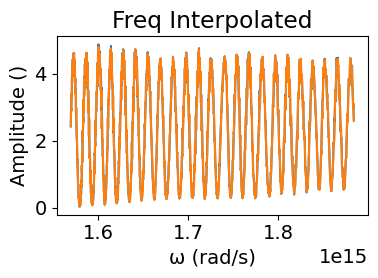

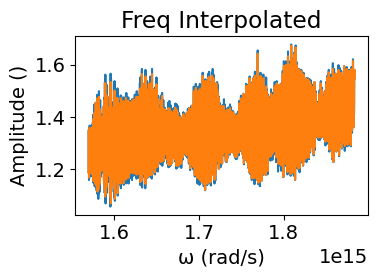

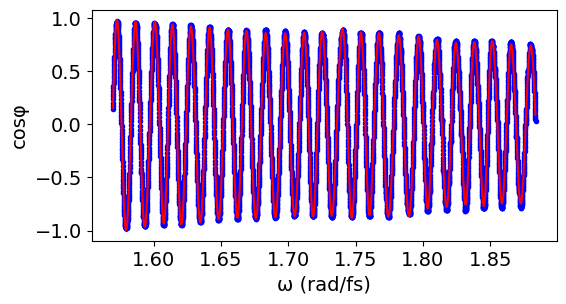

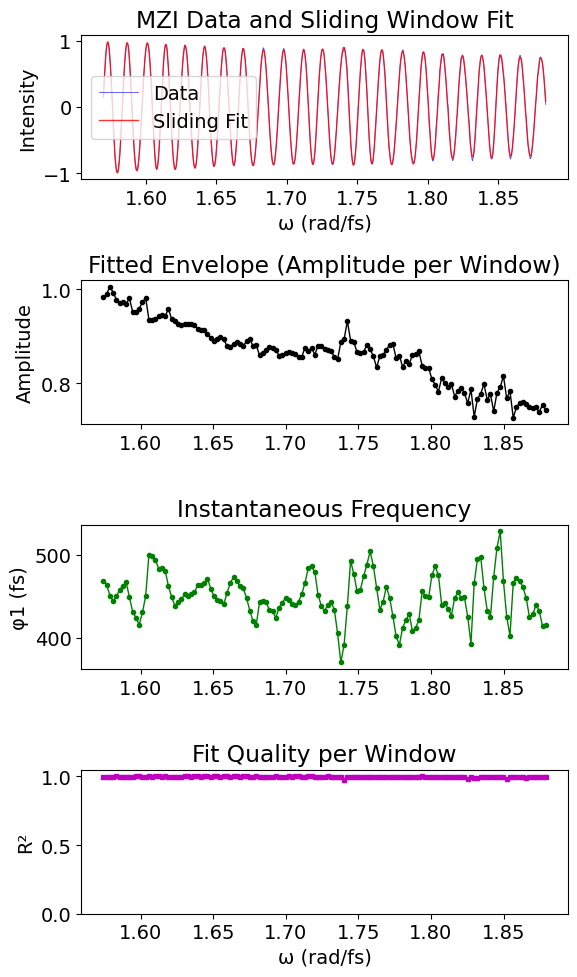

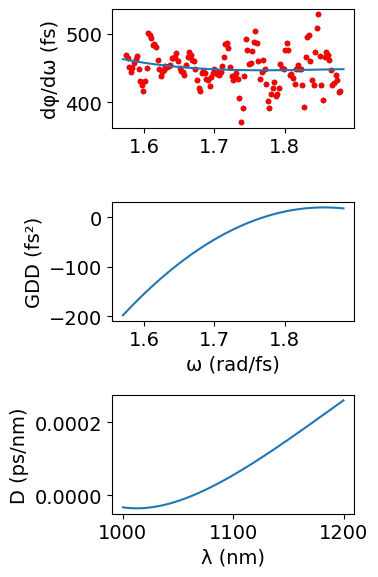

In [99]:
%matplotlib inline

n_interp = 5000
#---------------------------------------------------------------------
# Normalize out supercontinuum intensity dependence from MZI output
amp_norm = normalize_mzi(ds_mzi, ds_ref, ds_noise=ds_noise, verbose=False)
# Convert x axis to frequency and interpolate
ω_interp, amp_interp = spec_to_freq(ds_mzi['wavelength'], amp_norm, nsamp=n_interp, verbose=True)

#----------------------------------------------------------------------
# Placeholder for objective transmission - need to measure
T_obj = 1
# Calculate sample transmission
T_lin = calc_sample_T(ds_samp, ds_ref, ds_noise=ds_noise, verbose=False)
# Convert sample transmission vs wavelength to transmission vs frequency
_, T_interp = spec_to_freq(ds_samp['wavelength'], T_lin, nsamp=n_interp)
T = T_interp * T_obj**2

#------------------------------------------------------------------------
# Use calculated sample/objective transmission to extract cosφ term
cosφ = extract_cos(ω_interp, amp_interp, T, verbose=False, smooth=True, window_length=25, polyorder=3)
#Truncate cosφ to remove problematic regions
ω0 = ω_interp[0] #2.3 * u.rad/u.fs # 1.2 * u.rad/u.fs (1.2, 2.3)
ωf = ω_interp[-1] # 2.1 * u.rad/u.fs (ω_interp[-1], 2.1)
# ind_f = np.argmin(np.abs(ωf - ω_interp))
ω_trunc = ω_interp[(ω_interp > ω0) & (ω_interp < ωf)]
cosφ_trunc = cosφ[(ω_interp > ω0) & (ω_interp < ωf)]

num_periods = 1
pk_inds, _ = find_peaks(cosφ_trunc)
ω_len = (ω_trunc[-1] - ω_trunc[0]).to(u.rad/u.fs).m / pk_inds.shape[0] * num_periods
print(f"ω_len: {ω_len : 2.5f}")

results = fit_mzi(ω_trunc, cosφ_trunc, bounds=None, verbose=True, window_len=ω_len)
plot_sliding_fit_results(ω_trunc, cosφ_trunc, results)
fig, ax = calc_dispersion(ω_trunc, results, L_dev=None, medfilt_kernel=None, polyorder=3)
# ax[1].set_xlim((1.6, 1.8))
# ax[1].set_ylim((-100, 100))

# #-------------------------------------------------------------------------
# # Fit cos function and extract polynomial phase coefficients
# results = fit_mzi(ω_interp, cosφ, bounds=None, verbose=True, window_len=0.00378)
# plot_sliding_fit_results(ω_interp, cosφ, results)

# # --------------------------------------------------------------------------
# # Calculate dispersion from phase
# calc_dispersion(ω_interp, results, L_dev=None)

In [15]:
(u.c/(2.7*u.rad/u.fs / (2*np.pi))).to(u.nm)

697.6487286329086 <Unit('nanometer')>

In [54]:
0.05/15

0.0033333333333333335

# Experimenting with different dispersion extraction algorithms
1) Create a sliding window that segments into sections of 2-4 periods, then fit to $A\cos(\phi_1 \omega + \phi_0)$ to extract $\phi_1$.  Do polynomial fit of $\phi_1$ and take derivative of $\phi_1$ to get $\phi_2$
2) Extract the envelope functon $V(\lambda)$ by finding all the fringe maxima and absolute values of the minima.  Solve for the phase by taking $\cos^{-1}{(\frac{I(\lambda)}{V(\lambda)})}$. Then correct for center of symmetry $V(\lambda)=1$ and solve for sign of phase by monitoring direction of fringe shift as move delay stage.
3) Use a hilbert transform to extract the phase

3139419278848089.0 radian / second
2354564459136066.0 radian / second


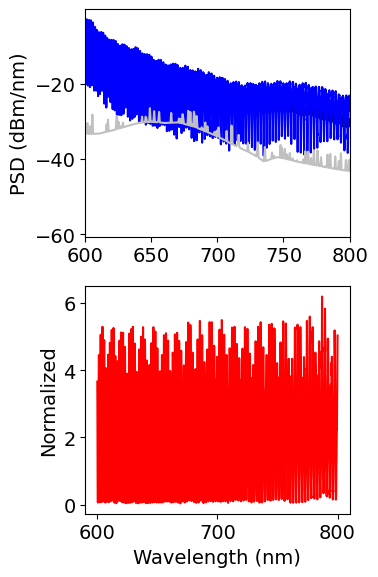

In [112]:
amp_norm = normalize_mzi(ds_mzi, ds_ref, ds_noise=ds_noise, verbose=True)
ω_raw = (2 * np.pi * u.c / (ds_mzi['wavelength'].to(u.nm).m * u.nm)).to(u.rad/ u.s)
print(ω_raw[0])
print(ω_raw[-1])



# Finally, we can relate our extracted phase to the dispersion coefficients by taking derivatives of the phase term.  
$$\phi(\omega)=\beta(\omega)L - \beta_0(\omega)L_0 = \beta(\omega)L - \frac{\omega}{c} L_0$$
$$\frac{\partial\phi}{\partial\omega} = \frac{\partial\beta(\omega)}{\partial\omega}L - \frac{L_0}{c} \Rightarrow \frac{\partial\beta(\omega)}{\partial\omega} = \frac{1}{L}\left[\frac{\partial\phi}{\partial\omega} + \frac{L_0}{c} \right]$$

$$\frac{\partial^2\phi}{\partial\omega^2} = \frac{\partial^2\beta(\omega)}{\partial\omega^2}L \Rightarrow \frac{\partial^2\beta(\omega)}{\partial\omega^2} = \frac{1}{L}\frac{\partial^2\phi}{\partial\omega^2} $$

$$\frac{\partial^3\phi}{\partial\omega^3} = \frac{\partial^3\beta(\omega)}{\partial\omega^3}L \Rightarrow \frac{\partial^3\beta(\omega)}{\partial\omega^3}=\frac{1}{L}\frac{\partial^3\phi}{\partial\omega^3}$$

$$\frac{\partial^4\phi}{\partial\omega^4} = \frac{\partial^4\beta(\omega)}{\partial\omega^4}L \Rightarrow \frac{\partial^4\beta(\omega)}{\partial\omega^4} = \frac{1}{L} \frac{\partial^4\phi}{\partial\omega^4}$$

At the same time, we can write down analytical expressions for the derivatives of our polynomial fit to the phase.
$$\phi(\omega) = \phi_0 + \phi_1\omega + \phi_2\omega^2 + \phi_3\omega^3 + \phi_4\omega^4$$
$$\frac{\partial\phi}{\partial\omega} = \phi_1 + \phi_2\omega + \phi_3\omega^2 + \phi_4\omega^3$$
$$\frac{\partial^2\phi}{\partial\omega^2} = \phi_2 + \phi_3\omega + \phi_4\omega^2$$
$$\frac{\partial^3\phi}{\partial\omega^3} = \phi_3 + \phi_4\omega$$
$$\frac{\partial^4\phi}{\partial\omega^4} = \phi_4$$

The final variable here is the sample length L, which we already know. We can calculate the dispersion parameter as:
$$ D(\lambda)=-\frac{2\pi c}{\lambda^2}\frac{\partial^2\beta}{\partial\omega^2}$$

In the simple case where the "sample" is just air (empty MZI), the phase expression above reduces to:
$$\phi(\omega)=\beta_0(\omega)L - \beta_0(\omega)L_0 = \frac{\omega}{c} (L-L_0)$$



In [272]:
(2*np.pi)/Δω.to(u.rad/u.s).m

2.8347277502224854e-13


Polynomial fit coefficients (order 3):
  φ_3 = 1.547150e+02  (rad/fs^3 term)
  φ_2 = -8.184582e+02  (rad/fs^2 term)
  φ_1 = 3.085039e+03  (rad/fs^1 term)
  φ_0 = -3.425847e+03  (rad/fs^0 term)


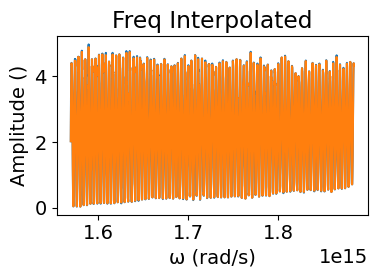

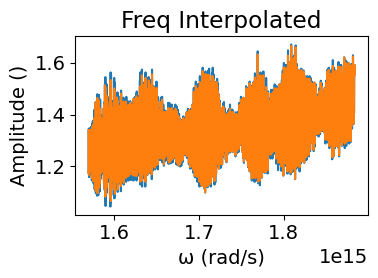

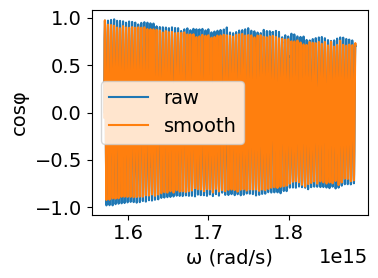

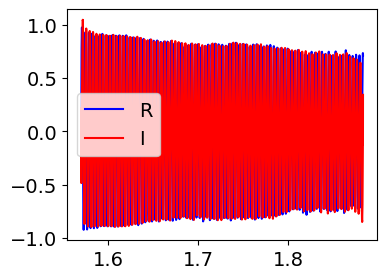

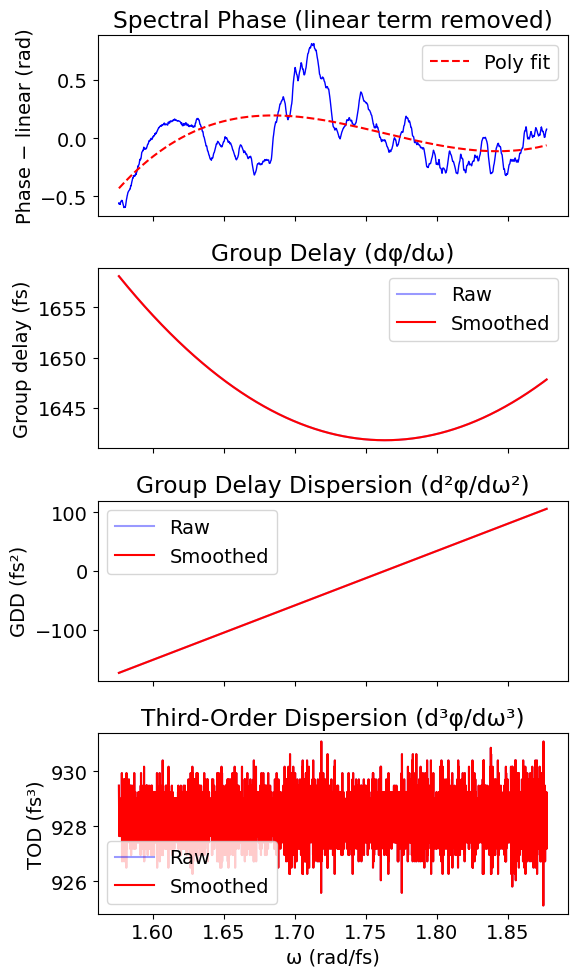

In [71]:
def extract_dispersion_hilbert(ω_interp, cosφ, L_dev=None, polyfit_order=None, smooth_gd=True, smooth_window=51, smooth_poly=3, verbose=True):
    """
    Extract spectral phase  φ(ω) from MZI fringes using the Hilbert transform.
    Params: 
    ----------
    - ω_interp : (Q_) interpolated for uniform frequency sampling
    - cosφ : after normalizing to sample T and supercontinuum spectrum to remove envelope and offset
    - L_dev : (Q_) device length 
    - polyfit_order : int or None - If set, fit a polynomial of this order to the unwrapped phase and use the polynomial for smoother derivatives.
    - smooth_gd : bool - Apply Savitzky-Golay smoothing to group delay and GDD.
    - smooth_window : int (odd) - Savgol window length (in points).
    - smooth_poly : int - Savgol polynomial order 
    - verbose : bool - Print summary.

    Returns:
    -------
    result : dict with keys:
        'ω'              : (Q_) angular frequency array
        'φ'              : (Q_) unwrapped spectral phase φ(ω)
        'φ_poly'         : (Q_) polynomial fit to phase (if polyfit_order set)
        'envelope'       : (Q_) extracted envelope A(ω)
        'analytic_signal': (Q_) complex analytic signal
        'ω_inst'         : (Q_) instantaneous fringe frequency
        'GDD'            : (Q_) d²φ/dω² — group delay dispersion
        'TOD'            : (Q_) d³φ/dω³ — third-order dispersion
        'GVD'            : (Q_) d²β/dω² - group velocity dispersion
    """
    
    dω = np.mean(np.diff(ω_interp.to(u.rad/u.fs).m))
    ω = ω_interp.to(u.rad/u.fs).m

    # Hilbert transform to create complex signal ───────────────
    analytic = hilbert(cosφ)
    # amp_inst = np.abs(analytic)
    φ_inst = np.unwrap(np.angle(analytic))

    if verbose:
        fig, ax = plt.subplots(1,1, figsize=(4,3))
        ax.plot(ω, np.real(analytic), label='R', color='blue')
        ax.plot(ω, np.imag(analytic), label='I', color='red')
        plt.legend()
    # Remove linear component (mean group delay) - (optional, for display) 
    # Keep it for dispersion extraction
    coeffs_linear = np.polyfit(ω, φ_inst, 1)
    φ_lin = np.polyval(coeffs_linear, ω)
    φ_nonlinear = φ_inst - φ_lin

    # Polynomial fit to phase (optional) ───────────────
    φ_poly = None
    φ_for_derivatives = φ_inst

    if polyfit_order is not None:
        coeffs = np.polyfit(ω, φ_inst, polyfit_order)
        φ_poly = np.polyval(coeffs, ω)
        φ_for_derivatives = φ_poly

        if verbose:
            print(f"\nPolynomial fit coefficients (order {polyfit_order}):")
            for i, c in enumerate(coeffs):
                order = polyfit_order - i
                print(f"  φ_{order} = {c:.6e}  (rad/fs^{order} term)")

    # Derivatives → group delay, GDD, TOD ─────────────
    group_delay = np.gradient(φ_for_derivatives, dω)  # dφ/dω
    GDD = np.gradient(group_delay, dω)                # d²φ/dω²
    TOD = np.gradient(GDD, dω)                        # d³φ/dω³

    # Smooth derivatives if requested ──────────────────
    if smooth_gd and polyfit_order is None:
        if smooth_window > len(group_delay):
            smooth_window = len(group_delay) // 2 * 2 + 1 #ensures odd value
        group_delay_smooth = savgol_filter(group_delay, smooth_window, smooth_poly)
        GDD_smooth = savgol_filter(GDD, smooth_window, smooth_poly)
        TOD_smooth = savgol_filter(TOD, smooth_window, smooth_poly)
    else:
        group_delay_smooth = group_delay
        GDD_smooth = GDD
        TOD_smooth = TOD
    

    # Instantaneous frequency (sanity check) ───────────
    ω_inst = np.gradient(φ_inst, dω) 

    # ── Trim edges (Hilbert artifacts) ───────────────────────────
    trim = max(len(ω) // 50, 10)
    sl = slice(trim, -trim)

    result = {
        'ω':                ω * u.rad/u.fs,
        'φ':                φ_inst * u.rad,
        'φ_nonlinear':      φ_nonlinear * u.rad,
        'φ_poly':           φ_poly * u.rad,
        'group_delay':      group_delay_smooth * u.fs,
        'GDD':              GDD_smooth * u.fs**2,
        'TOD':              TOD_smooth * u.fs**3,
        # 'GVD':              (GDD_smooth * u.fs**2 / L_dev).to(u.fs/u.mm**2),
        'L_dev':            L_dev,
        'group_delay_raw':  group_delay * u.fs,
        'GDD_raw':          GDD * u.fs**2,
        'TOD_raw':          TOD * u.fs**3,
        'analytic_signal':  analytic,
        'ω_inst':           ω_inst * u.rad/u.fs,
        'trim_slice':       sl,
        'linear_coeffs':    coeffs_linear,
    }
    
    if verbose:
        plot_dispersion(result, wavelength_axis=False)

    return result


def get_dispersion_values(λ_select, result: dict):
    """
    Print dispersion values at select wavelength
    Params: λ_select (Q_), result - output of extract_dispersion_hilbert
    """
    
    ω_select = 2 * np.pi * u.c / λ_select
    
    # Find dispersion values corresponding to ω_select
    ind = np.abs(np.min(ω_select - result['ω']))
    τ_g = result['group_delay'][ind]
    GDD = result['GDD'][ind]
    GVD = (result['GDD'][ind] / result['L_dev']).to(u.fs**2 / u.mm)
    TOD = result['TOD'][ind]
    
    print("\n" + "=" * 65)
    print(" Extracted Dispersion (Hilbert Transform)")
    print("=" * 65)
    print(f"  Group delay (dφ/dω)  = {τ_g.to(u.fs):.6e}")
    print(f"  GDD  (d²φ/dω²)         = {GDD:.6e}")
    print(f"  GVD  (d²β/dω²)         = {GVD:.6e}")
    print(f"  TOD  (d³φ/dω³)         = {TOD:.6e}")
    print("-" * 65)
    print(f"  τ_g range: [{np.min(result['group_delay'][result['sl']]) :.2f}, "
          f"{np.max(result['group_delay'][result['sl']]) :.2f}]")
    print(f"  GDD range: [{np.min(result['GDD'][result['sl']]) :.2f}, "
          f"{np.max(result['GDD'][result['sl']]) :.2f}]")
    print("=" * 65)


def plot_dispersion(result, wavelength_axis=False, figsize=(6,10)):
    """
    Plot extracted dispersion 
    Params:
    ----------
    result : dict from extract_dispersion_hilbert
    wavelength_axis : bool - If True, plot vs wavelength instead of frequency.
    """
    sl = result['trim_slice']
    ω = result['ω']
    if result['L_dev'] is None:
        y2_raw = result['GDD_raw'][sl].to(u.fs**2)
        y2 = result['GDD'][sl].to(u.fs**2)
        y2_label = 'GDD (fs²)'
        y2_title = 'Group Delay Dispersion (d²φ/dω²)'
        
        y3_raw = result['TOD_raw'][sl].to(u.fs**3)
        y3 = result['TOD'][sl].to(u.fs**3)
        y3_label = 'TOD (fs³)'
        y3_title = 'Third-Order Dispersion (d³φ/dω³)'
        
        
    else:
        y2_raw = (result['GDD_raw'][sl] / result['L_dev']).to(u.fs**2 / u.mm)
        y2 = (result['GDD'][sl] / result['L_dev']).to(u.fs**2 / u.mm)
        y2_label = 'GVD (fs²/mm)'
        y2_title = 'Group Velocity Dispersion (d²β/dω²)'
        
        y3_raw = (result['TOD_raw'][sl] / result['L_dev']).to(u.fs**3 / u.mm)
        y3 = (result['TOD'][sl] / result['L_dev']).to(u.fs**3 / u.mm)
        y3_label = 'TOD (fs³/mm)'
        y3_title = 'Third-Order Dispersion (d³β/dω³)'

    if wavelength_axis:
        x_axis = (2 * np.pi * u.c / ω).to(u.nm)
        xlabel = 'Wavelength (nm)'
        x_axis = x_axis[sl]
    else:
        x_axis = ω[sl].to(u.rad/u.fs)
        xlabel = 'ω (rad/fs)'

    fig, ax = plt.subplots(4, 1, figsize=figsize, sharex=True)

    # Unwrapped phase (nonlinear part)
    ax[0].plot(x_axis, result['φ_nonlinear'][sl], 'b-', lw=1)
    if result['φ_poly'] is not None:
        φ_poly_nl = (result['φ_poly'].m - np.polyval(result['linear_coeffs'], ω.to(u.rad/u.fs).m))
        ax[0].plot(x_axis, φ_poly_nl[sl], 'r--', lw=1.5, label='Poly fit')
        ax[0].legend()
    ax[0].set_ylabel('Phase − linear (rad)')
    ax[0].set_title('Spectral Phase (linear term removed)')

    # Group delay
    ax[1].plot(x_axis, result['group_delay_raw'][sl].to(u.fs), 'b-', lw=1.5, alpha=0.4, label='Raw')
    ax[1].plot(x_axis, result['group_delay'][sl].to(u.fs), 'r-', lw=1.5, label='Smoothed')
    ax[1].set_ylabel('Group delay (fs)')
    ax[1].legend()
    ax[1].set_title('Group Delay (dφ/dω)')

    # GDD
    ax[2].plot(x_axis, y2_raw, 'b-', lw=1.5, alpha=0.4, label='Raw')
    ax[2].plot(x_axis, y2, 'r-', lw=1.5, label='Smoothed')
    ax[2].set_ylabel(y2_label)
    ax[2].legend()
    ax[2].set_title(y2_title)

    # TOD
    ax[3].plot(x_axis, y3_raw, 'b-', lw=1.5, alpha=0.4, label='Raw')
    ax[3].plot(x_axis, y3, 'r-', lw=1.5, label='Smoothed')
    ax[3].set_ylabel(y3_label)
    ax[3].set_xlabel(xlabel)
    ax[3].legend()
    ax[3].set_title(y3_title)

    plt.tight_layout()
    plt.show()


# ── Run ───────────────────────────────────────────────────────────────
%matplotlib inline

n_interp = 5000
#---------------------------------------------------------------------
# Normalize out supercontinuum intensity dependence from MZI output
amp_norm = normalize_mzi(ds_mzi, ds_ref, ds_noise=ds_noise, verbose=False)
# Convert x axis to frequency and interpolate
ω_interp, amp_interp = spec_to_freq(ds_mzi['wavelength'], amp_norm, nsamp=n_interp, verbose=True)

#----------------------------------------------------------------------
# Placeholder for objective transmission - need to measure
T_obj = 1
# Calculate sample transmission
T_lin = calc_sample_T(ds_samp, ds_ref, ds_noise=ds_noise, verbose=False)
# Convert sample transmission vs wavelength to transmission vs frequency
_, T_interp = spec_to_freq(ds_samp['wavelength'], T_lin, nsamp=n_interp)
T = T_interp * T_obj**2

#------------------------------------------------------------------------
# Use calculated sample/objective transmission to extract cosφ term
ω0 = ω_interp[0] #2.3 * u.rad/u.fs
ωf = ω_interp[-1] #3.139 * u.rad/u.fs
cosφ = extract_cos(ω_interp[(ω_interp > ω0) & (ω_interp < ωf)], amp_interp[(ω_interp > ω0) & (ω_interp < ωf)], T[(ω_interp > ω0) & (ω_interp < ωf)], verbose=True, smooth=True, window_length=40, polyorder=3)


result = extract_dispersion_hilbert(
    ω_interp        = ω_interp[(ω_interp > ω0) & (ω_interp < ωf)],           
    cosφ            = cosφ,          
    L_dev           = None,     
    polyfit_order   = 3,         
    smooth_gd       = True,           
    smooth_window   = 5,         
    smooth_poly     = 3,
    verbose         = True
)




set group delay:  628.319
ZDW = 941.826 nanometer


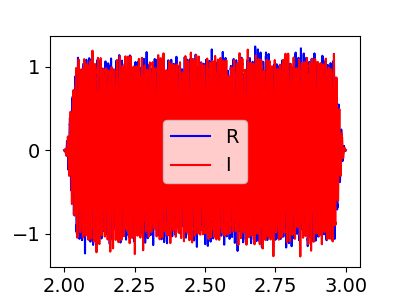

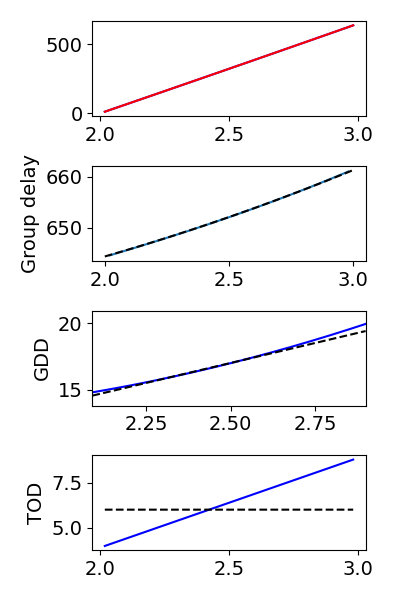

In [149]:
# Test hilbert transform with simple cosine

from scipy.interpolate import UnivariateSpline
from scipy.signal import savgol_filter
from scipy.signal.windows import tukey


%matplotlib ipympl


spline = False
sgolay = False
polyfit_order=4



# ω = np.linspace(-50, 50, N)
dω = 0.0001 #np.mean(np.diff(ω))
# ω = np.arange(-10, 10, dω)
ω = np.arange(2, 3, dω)
N = ω.shape[0]

ω_left = np.arange(-10, 2, dω)
ω_right = np.arange(3, 10, dω)

# pad_ω0 = -50
# pad_ωf = 50
# pad_front = np.arange(pad_ω0, ω[0], dω)
# pad_end = np.arange(ω[-1] + dω, pad_ωf, dω)
# ω_pad = np.concatenate((pad_front, ω, pad_end))
# plt.figure()
# plt.plot(np.diff(ω_pad))

# ω = ω_pad
# cosφ = extract_cos(ω_interp[ind_0:ind_1], amp_interp[ind_0:ind_1], T[ind_0:ind_1], verbose=True, smooth=False, window_length=5, polyorder=3)
cosφ = np.cos(2*np.pi / (0.01)* ω + ω**2 + ω**3)
cosφ_left = np.cos(2*np.pi / (0.01)* ω_left )
cosφ_right = np.cos(2*np.pi / (0.01)* ω_right )

x_padded = np.concatenate([cosφ_left, cosφ, cosφ_right])
w = tukey(len(x_padded), alpha=0.05)
analytic = hilbert(x_padded)[cosφ_left.shape[0]:cosφ_left.shape[0]+N]
φ_inst = np.unwrap(np.angle(analytic))


# Mirror padding cosφ as is worsens Gibbs ringing due to discontinuity at boundaries.  Truncate cosφ at boundaries so ends at a peak, then mirror
pk_inds, _ = find_peaks(cosφ)
ω_trunc = ω[pk_inds[0]:pk_inds[-1]]
cosφ_trunc = cosφ[pk_inds[0]:pk_inds[-1]]

# pad = cosφ_trunc.shape[0]
# x_padded = np.concatenate([cosφ_trunc[pad:0:-1], cosφ_trunc, cosφ_trunc[-2:-pad-2:-1]])
# w = tukey(len(x_padded), alpha=0.05)
# analytic = hilbert(x_padded * w)[pad:pad+N]
# φ_inst = np.unwrap(np.angle(analytic))



# pad = cosφ_trunc.shape[0]
# x_padded = np.concatenate([cosφ_trunc, cosφ_trunc[pad-1:0:-1], cosφ_trunc, cosφ_trunc[-2:-pad-3:-1], cosφ_trunc])
# w = tukey(len(x_padded), alpha=0.05)
# analytic = hilbert(x_padded)[2*pad:2*pad+N]
# φ_inst = np.unwrap(np.angle(analytic))





trim = max(len(ω) // 50, 10)
sl = slice(trim, -trim)





# add random noise
noise = np.random.normal(0, 0.2, cosφ.shape)
cosφ += noise

# smooth random noise before taking hilbert transform
cosφ = savgol_filter(cosφ, window_length=15, polyorder=3)

# Hilbert transform to create complex signal ───────────────
w = tukey(len(cosφ), alpha=0.1)
analytic = hilbert(cosφ*w)
φ_inst = np.unwrap(np.angle(analytic))
amp = np.abs(analytic)

# plt.figure()
# plt.plot(x_padded*w)



fig, ax = plt.subplots(1,1, figsize=(4,3))
# ax.plot(ω, cosφ, label='O', color='k', lw=3)
ax.plot(ω, np.real(analytic), label='R', color='blue')
ax.plot(ω, np.imag(analytic), label='I', color='red')
# ax.plot(ω, amp, label='|z(ω)|')
plt.legend()



# Remove linear component (mean group delay) - (optional, for display) 
# Keep it for dispersion extraction
# coeffs_linear = np.polyfit(ω, φ_inst, 1)
# φ_lin = np.polyval(coeffs_linear, ω)
# φ_nonlinear = φ_inst - φ_lin
φ_for_derivatives = φ_inst

# Polynomial fit to phase (optional) ───────────────
# φ_poly = None

if polyfit_order is not None:
    p = np.polynomial.Polynomial.fit(ω[sl], φ_inst[sl], deg=polyfit_order)
    group_delay  = p.deriv(1)(ω)
    GDD = p.deriv(2)(ω)
    TOD = p.deriv(3)(ω)   
    
elif spline:
    φ_spl = UnivariateSpline(ω[sl], φ_inst[sl], k=3, s=100)
    group_delay = φ_spl.derivative(n=1)(ω) 
    GDD = φ_spl.derivative(n=2)(ω)
    TOD = φ_spl.derivative(n=3)(ω)
    
elif sgolay:
    group_delay  = savgol_filter(φ_inst, window_length=201, polyorder=4, deriv=1, delta=dω)
    GDD = savgol_filter(φ_inst, window_length=301, polyorder=4, deriv=2, delta=dω)
    TOD = savgol_filter(φ_inst, window_length=401, polyorder=5, deriv=3, delta=dω)
    
else:
    # Derivatives → group delay, GDD, TOD ─────────────
    group_delay = np.gradient(φ_for_derivatives, dω)  # dφ/dω
    GDD = np.gradient(group_delay, dω)                # d²φ/dω²
    TOD = np.gradient(GDD, dω)        


zd = (ω[np.nanargmin(np.abs(GDD))]*u.rad/u.fs)
zdw = (2*np.pi*u.c / zd).to(u.nm)

fig, ax = plt.subplots(4,1, figsize=(4,6), tight_layout=True)
# ax[0].plot(ω, φ_inst, label='orig', color='b')
# ax[0].plot(ω, φ_for_derivatives, label='poly', color='r')
ax[0].plot(ω[sl], φ_inst[sl], label='orig', color='b')
ax[0].plot(ω[sl], φ_for_derivatives[sl], label='poly', color='r')
ax[1].plot(ω[sl], group_delay[sl])
ax[1].set_ylabel('Group delay')
# ax[1].set_ylim((0,700))
ax[1].plot(ω, (2*np.pi / (0.01) + 2*ω + 3*ω**2) * np.ones(group_delay.shape), color='k', linestyle='--')
ax[2].plot(ω[sl], GDD[sl], label='O', color='blue')
ax[2].set_ylabel('GDD')
ax[2].set_xlim((2.09, 2.9))
# ax[2].set_ylim((-50,50))
ax[2].plot(ω[sl], (2 + 6*ω[sl]) * np.ones(GDD[sl].shape), color='k', linestyle='--')
ax[3].plot(ω[sl], TOD[sl], label='O', color='blue')
ax[3].plot(ω[sl], (6) * np.ones(GDD[sl].shape), color='k', linestyle='--')
ax[3].set_ylabel('TOD')
print(f"set group delay: {2*np.pi / (0.01) : 2.3f}")

print(f'ZDW = {zdw: 2.3f}')

In [100]:
ω.shape

(1000,)

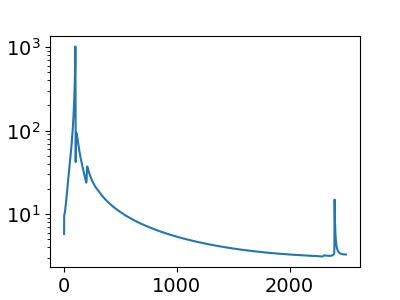

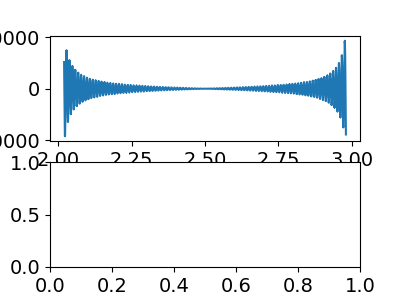

In [ ]:
# Inspecting FFT of the Gibbs oscillations - transients, so not localized in frequency - difficult to remove by filtering.  Better to address before taking the Hilbert transform
sig = GDD

fft_mag = np.abs(np.fft.rfft(sig[sl])) / sig[sl].shape[0] * 2
freqs = np.fft.rfftfreq(n=ω[sl].shape[0], d=dω)

A = np.max(fft_mag) # Approximate magnitude of cos
peak_ind = np.argmax(fft_mag[1:]) + 1 # skip DC
Δω = 1/freqs[peak_ind]



fig, ax = plt.subplots(1,1, figsize=(4,3))
ax.plot(freqs, fft_mag)
ax.set_yscale('log')
ax.set_xlabel("ω (rad/s)")
ax.set_ylabel("Power (W)")

fig, ax = plt.subplots(2,1, figsize=(4,3))
ax[0].plot(ω[sl], sig[sl])

In [29]:
fs = 200.0  # Sample frequency (Hz)
f0 = 60.0  # Frequency to be removed from signal (Hz)
Q = 30.0  # Quality factor
# Design notch filter
b, a = signal.iirnotch(f0, Q, fs)

In [32]:
fs = np.diff(freqs)
fs

array([1.04145833, 1.04145833, 1.04145833, ..., 1.04145833, 1.04145833,
       1.04145833])

In [246]:
zd

2.623343271581838 <Unit('radian / femtosecond')>

In [ ]:
# Old obsolete code
def get_Δω(ω, amps, verbose=False):
    # Find fringe spacing for initial fitting parameter guess
    # Inputs: ω (Q_), amps (unitless)
    # Return: Δω of fringe spacing, A amplitude of cos
    
    pk_ind, _ = find_peaks(amps, prominence=np.std(amps) * 0.3, distance=10, height=0)
    if len(pk_ind) >= 2:
        # print(np.diff(ω[pk_ind]))
        Δω = np.median(np.diff(ω[pk_ind]))
        A = np.max(amps[pk_ind])
        print(f"Estimated Δω = {Δω:.3e}")
        print(f"Estimated Δf = {Δω/(2*np.pi):.3e}")
        
        if verbose:
            fig, ax = plt.subplots(1,1, figsize=(4,3))
            ax.plot(ω, amps)
            ax.scatter(ω[pk_ind], amps[pk_ind], marker='x', color='k')
            ax.set_xlabel("ω (rad/s)")
            ax.set_ylabel("Power (W)")
    else:
        # Order of magnitude value for initial guess
        Δω = 1.00e-02 * u.rad/u.s
        print(f"find_peaks() can't extract fringe spacing")
    return Δω, A


def fit_mzi(ω_interp, cosφ, p0=None, bounds=None, verbose=True):
    # Fit cosφ term, assuming polynomial phase.  Return dict of extracted phase coefficients.
    
    # Convert ω to rad/fs so large numbers doesn't break fitting
    ω_scale = (ω_interp.to(u.rad/u.fs)).m
    Δω, A = get_Δω(ω=ω_scale, amps=cosφ, verbose=True)

    # Initial phase needs to be close or fit will fail. Need to smooth out local extrema from noise for this to work!
    if p0 is None:
        φ0_0 = np.arccos(cosφ[0]/A)
        # Check point to right.  If lower, on decreasing edge. If higher, on increasing edge. 
        ind = 1
        if cosφ[ind] > cosφ[0]: # increasing edge, pos phase shift
            φ0_0 *= -1
        elif cosφ[ind] < cosφ[0]: #decreasing edge, neg phase shift
            φ0_0 *= 1

        p0 = [A, φ0_0 - ω_scale[0]*(2*np.pi)/Δω, (2*np.pi)/Δω, 0, 0, 0]
        
    y = mzi_func(ω_scale, *p0)

    if bounds is None:
        bounds = (
            [-np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf],
            [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf]
        )

    popt, pcov = curve_fit(mzi_func, ω_scale, cosφ, p0=p0, method='trf', maxfev=100000, bounds=bounds)
    scaled_fit = mzi_func(ω_scale, *popt) 
    
    # Calculate 1 std of error on parameters
    perr = np.sqrt(np.diag(pcov)) if np.all(np.isfinite(pcov)) else [np.nan]*len(popt)

    if verbose:
        fig, ax = plt.subplots(1,1, figsize=(4,3))
        ax.plot(ω_scale, cosφ, label='raw')
        ax.plot(ω_scale, y, label='p0', color='silver', linestyle=':')
        # ax.plot(ω_scale, scaled_fit/np.max(scaled_fit), label='fit')
        ax.plot(ω_scale, scaled_fit, label='fit')

        ax.set_xlabel("(ω x 1e-15 (rad/s))")
        ax.set_ylabel("Normalized")

    # Calculate rescaled phase coefficients from popt
    A = popt[0]

    φ_coeff = dict(
        φ0 = popt[1] * u.rad,
        φ1 = popt[2] * u.fs,
        φ2 = popt[3] * u.fs**2,
        φ3 = popt[4] * u.fs**3,
        φ4 = popt[5] * u.fs**4
    )
    
    φ_error = dict(
        φ0 = perr[1] * u.rad,
        φ1 = perr[2] * u.fs,
        φ2 = perr[3] * u.fs**2,
        φ3 = perr[4] * u.fs**3,
        φ4 = perr[5] * u.fs**4
    )

    # Print fit results|
    print("\n" + "=" * 60)
    print(f"Extracted Phase Coefficients")
    print("=" * 60)
    for coeff, value in φ_coeff.items():
    # for coeff, value, err in zip(names, popt, perr):
        # print(f"  {name:20s} = {val:14.6e} ± {err:.2e}")
        print(f"{coeff}: {value : 2.3e} ± {φ_error[coeff]:.2e}")
    
    return φ_coeff, φ_error


def calc_dispersion(ω_segs, φ_coeffs: list, φ_errors: list, L_dev, verbose=True):
    # Calculate GVD
    # Params: φ_coeffs: list of dicts, φ_errors: list of dicts
    
    ω = ω_segs.flatten()
    λ = 2* np.pi * u.c / ω

    # Construct φ(ω) and its derivatives
    φ, dφ_dω, d2φ_dω2, d3φ_dω3, d4φ_dω4 = [], [], [], [], []
    
    for i, φ_coeff in enumerate(φ_coeffs):
        φ = np.append(φ, (φ_coeff["φ0"] + φ_coeff["φ1"]*ω_segs[i] + φ_coeff["φ2"]*ω_segs[i]**2 + φ_coeff["φ3"]*ω_segs[i]**3 + φ_coeff["φ4"]*ω_segs[i]**4).to(u.rad).m)
        dφ_dω = np.append(dφ_dω, (φ_coeff["φ1"] + φ_coeff["φ2"]*ω_segs[i] + φ_coeff["φ3"]*ω_segs[i]**2 + φ_coeff["φ4"]*ω_segs[i]**3).to(u.fs).m)
        d2φ_dω2 = np.append(d2φ_dω2, (φ_coeff["φ2"] + φ_coeff["φ3"]*ω_segs[i] + φ_coeff["φ4"]*ω_segs[i]**2).to(u.fs**2).m)
        d3φ_dω3 = np.append(d3φ_dω3, (φ_coeff["φ3"] + φ_coeff["φ4"]*ω_segs[i]).to(u.fs**3).m)
        d4φ_dω4 = np.append(d4φ_dω4, (φ_coeff["φ4"] * np.ones(ω_segs[i].shape)).to(u.fs**4).m)

    φ *= u.rad
    dφ_dω *= u.fs
    d2φ_dω2 *= u.fs**2
    d3φ_dω3 *= u.fs**3
    d4φ_dω4 *= u.fs**4
    
    # Construct derivative of β(ω)
    d2β_dω2 = (1/L_dev * d2φ_dω2).to(u.fs**2 / u.mm)
    d3β_dω3 = (1/L_dev * d3φ_dω3).to(u.fs**3 / u.mm)
    d4β_dω4 = (1/L_dev * d4φ_dω4).to(u.fs**4 / u.mm)

    D_λ = (-2*np.pi*u.c / λ**2 * d2β_dω2).to(u.ps/(u.nm*u.km))

    if verbose:
        fig, ax = plt.subplots(5,1, figsize=(4,10), tight_layout=True)
        ax[0].plot(ω, φ)
        ax[0].set_ylabel("φ (rad)")
        ax[1].plot(ω, dφ_dω)
        ax[1].set_ylabel("dφ/dω (fs)")
        ax[2].plot(ω, d2β_dω2)
        ax[2].set_ylabel("$d^2β/dω^2 (fs^2/mm)$")
        ax[3].plot(ω, d3β_dω3)
        ax[3].set_ylabel("$d^3β/dω^3 (fs^3/mm$")
        ax[4].plot(ω, d4β_dω4)
        ax[4].set_ylabel("$d^4β/dω^4 (fs^4/mm)$")
        ax[4].set_xlabel("ω (rad/s)")

        fig, ax = plt.subplots(1,1, figsize=(4,3), tight_layout=True)
        ax.plot(ω, D_λ)
        ax.set_ylabel("D [ps/(nm km)]")
        ax.set_xlabel("ω (rad/s)")
    
    return ω, d2β_dω2